In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
df = pd.read_csv('business_cleaned.csv')

In [5]:
df['via_city'] = df['via_city'].fillna(
    pd.Series(np.where(df['stop_count'] == 0, 'Direct', 'Not_Recorded'), index=df.index)
)

In [6]:
df.sample(10)

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,days_left,price
10525,2022-03-03,Vistara,UK,975,Delhi,Kolkata,Not_Recorded,Delhi-Kolkata,1,19,Evening,5,Late_Night,850,21,65529
60421,2022-03-28,Air India,AI,765,Kolkata,Mumbai,Not_Recorded,Kolkata-Mumbai,1,8,Morning,14,Afternoon,1045,46,43711
49139,2022-03-29,Vistara,UK,808,Bangalore,Kolkata,Not_Recorded,Bangalore-Kolkata,1,18,Evening,8,Morning,605,47,60508
80762,2022-03-27,Air India,AI,420,Hyderabad,Chennai,STV,Hyderabad-Chennai,1,23,Night,16,Afternoon,1895,45,51595
22311,2022-03-22,Vistara,UK,873,Mumbai,Delhi,Not_Recorded,Mumbai-Delhi,1,19,Evening,6,Morning,815,40,41269
54529,2022-03-30,Vistara,UK,854,Bangalore,Chennai,Not_Recorded,Bangalore-Chennai,1,8,Morning,18,Evening,865,48,44280
31450,2022-02-13,Vistara,UK,958,Mumbai,Hyderabad,Not_Recorded,Mumbai-Hyderabad,1,22,Night,12,Afternoon,630,3,71229
86526,2022-03-27,Vistara,UK,832,Chennai,Mumbai,Not_Recorded,Chennai-Mumbai,1,18,Evening,7,Morning,675,45,71483
21999,2022-03-19,Air India,AI,619,Mumbai,Delhi,Not_Recorded,Mumbai-Delhi,1,18,Evening,20,Night,1335,37,41101
77530,2022-03-09,Vistara,UK,890,Hyderabad,Kolkata,Not_Recorded,Hyderabad-Kolkata,1,18,Evening,17,Evening,1465,27,51819


## `Feature Engineering` (day_of_week and duration_bucket is added here rest are added while cleaning)
**`route` column is derived from joining `from` & `to`**

**`arr_period` & `dep_period` columns are added by bucketing the `arr_hrs` & `dep_hrs` into day-cycle**

**`stop_count` is extarcted containing only number of stoppages**

**`via_city` is added by extracting the stop column**

**`day_of_week` is added by extracting the days from the date column then `is_weekend` is by extracting weekends from `day_of_week`**

**`duration_bucket` is added by dividing the duration_hrs into bins of 200**

In [7]:
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.day_name()

df['is_weekend'] = np.where(df['day_of_week'].isin(['Saturday','Sunday']), 1, 0)

In [8]:
df['duration_bucket'] = (df['duration_mins'] // 200) * 200

In [9]:
order = ['date', 'day_of_week','is_weekend', 'airline', 'ch_code', 'flight_number', 'from', 'to',
         'via_city','route', 'stop_count', 'arr_hour', 'arr_period', 'dep_hour',
         'dep_period', 'duration_mins', 'duration_bucket', 'days_left', 'price'
        ]

df = df[order]
df.columns

Index(['date', 'day_of_week', 'is_weekend', 'airline', 'ch_code',
       'flight_number', 'from', 'to', 'via_city', 'route', 'stop_count',
       'arr_hour', 'arr_period', 'dep_hour', 'dep_period', 'duration_mins',
       'duration_bucket', 'days_left', 'price'],
      dtype='object')

## Dropping unneccessary columns

In [10]:
df.drop(columns=['date','ch_code','duration_bucket'], inplace= True)

In [11]:
X = df.drop(columns=['price'])
y = df['price']


In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state=42)

In [13]:
X_train.sample(5)

,day_of_week,is_weekend,airline,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,days_left
45082,Saturday,1,Air India,505,Bangalore,Mumbai,Not_Recorded,Bangalore-Mumbai,1,21,Night,10,Morning,670,37
63376,Monday,0,Vistara,772,Kolkata,Bangalore,Not_Recorded,Kolkata-Bangalore,1,10,Morning,10,Morning,1460,46
18065,Monday,0,Air India,665,Delhi,Chennai,Not_Recorded,Delhi-Chennai,1,10,Morning,8,Morning,1615,46
57953,Monday,0,Vistara,720,Kolkata,Mumbai,Not_Recorded,Kolkata-Mumbai,1,17,Evening,7,Morning,630,11
28334,Wednesday,0,Vistara,986,Mumbai,Kolkata,Not_Recorded,Mumbai-Kolkata,1,9,Morning,22,Night,650,13


In [14]:
X_test.sample(5)

,day_of_week,is_weekend,airline,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,days_left
90977,Tuesday,0,Vistara,836,Chennai,Kolkata,Not_Recorded,Chennai-Kolkata,1,18,Evening,10,Morning,440,40
55893,Sunday,1,Vistara,776,Kolkata,Delhi,Not_Recorded,Kolkata-Delhi,1,8,Morning,17,Evening,870,24
43479,Tuesday,0,Air India,505,Bangalore,Mumbai,Not_Recorded,Bangalore-Mumbai,1,20,Night,10,Morning,575,19
56201,Friday,0,Vistara,772,Kolkata,Delhi,Not_Recorded,Kolkata-Delhi,1,21,Night,10,Morning,670,29
39431,Monday,0,Vistara,854,Bangalore,Delhi,Not_Recorded,Bangalore-Delhi,1,8,Morning,18,Evening,820,18


-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------
##                                                       LinearRegressor Model
-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------

In [15]:
categorical_features = ['day_of_week','airline','from','to','route','arr_period','dep_period','via_city']

numerical_features = ['stop_count','days_left', 'flight_number','duration_mins']

binary_count = ['is_weekend']

In [16]:
# preprocessing for LinearRegression
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown= 'ignore'), categorical_features),
    ('bin', 'passthrough', binary_count)
])

In [17]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [18]:
X_train_encoded.shape

(74789, 82)

In [19]:
X_test.shape

(18698, 15)

In [20]:
lr = LinearRegression()

In [21]:
lr.fit(X_train_encoded,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Shape[1] of X_train after preprocessing will be equal to the number of coefficients of the Linear Regression equation** 

In [22]:
print('Coefficients of linear regression:',lr.coef_)

print('\nintercept:',lr.intercept_)

Coefficients of linear regression: [  3743.7291267   -1219.3995872     631.63876839   -730.82934288
   -308.16681318    -50.18315292    600.5227634    -153.34034658
   -214.49958782   -107.9549629    6740.20039189   1601.7891671
   -347.68006203  -1532.21865677   4569.29079551   2231.60127069
  -1836.38373591  -1264.31901046  -2622.3684272    3639.78366896
   1699.22546769   -485.69405725   -788.61286413   1744.18708307
   5076.43434443  -1977.19997846   1647.56896412   -511.54101626
    176.43189909   2266.52929825  -1093.66897679   3502.0507782
  -1402.6099254    3051.59469381  -4405.04663138  -1742.26992745
   1835.31266548  -1300.67247221   -460.87342879    136.28450567
    877.84755054   1530.45419515   3241.16512922    294.7999702
  -1374.97604895   4319.35337153   3364.89564578  -4366.68657485
   -214.40459184   -871.55658015   1493.44111483   2345.77666782
    624.49061912   2611.44553179   2370.71517656   2294.72260742
   1278.82744192   1443.8464748   -1288.29507095    156.94

In [23]:
y_pred_lr = lr.predict(X_test_encoded) 

## Linear Regression — Summary

- Numeric features `StandardScaler` se scale kiye (LR scale-sensitive hota hai)
- Categorical `OneHotEncoder(drop='first')` se encode kiye
- Bug fix: `arr_period`/`dep_period` (bucketed) use kiya, raw `arr_hour`/`dep_hour` nahi — warna cyclical hour ka false-linearity issue aata (23 aur 0 ghante real mein paas hain, numerically door)
- **R² = 0.5613, RMSE = ₹8,613 (16.19% of median price)**
- RF/XGB se kaafi peeche hai — wajah: `stop_count`, `duration_mins`, `days_left` sab non-linear/threshold-shaped hain, jo LR ek straight line se represent nahi kar sakta

-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------
##                                                       RandomForestRegressor Model
-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------

**Since random forest works fine with outliers in Regression than Linear regression therefore we are feeding features without bucketng them**

**Scaling is also not needed here**

In [24]:
categorical_features = ['day_of_week','airline','from','to','route']

numerical_features = ['stop_count','days_left', 'flight_number','arr_hour','dep_hour','duration_mins']

binary_features = ['is_weekend']

In [25]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown= 'ignore'), categorical_features),
    ('bin', 'passthrough', binary_features)
])

In [26]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [27]:
X_train_encoded.shape

(74789, 53)

In [28]:
X_test.shape

(18698, 15)

In [29]:
rf = RandomForestRegressor(
    n_estimators=200,       # number of trees — more = more stable predictions, diminishing returns past ~200-300
    max_depth=15,           # cap tree depth — prevents individual trees from overfitting to noise
    min_samples_split=5,    # minimum samples needed to split a node — higher = less overfitting
    min_samples_leaf=2,     # minimum samples allowed in a leaf — smooths out predictions
    max_features='sqrt',    # each split considers only a random subset of features — reduces correlation between trees
    n_jobs=-1,               # use all CPU cores — speeds up training significantly
    random_state=42          # fixes randomness so results are reproducible
)

In [30]:
rf.fit(X_train_encoded,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred_rf = rf.predict(X_test_encoded) 

## Random Forest — Summary

- Scaling nahi ki (tree splits scale-invariant hote hain)
- Raw `arr_hour`/`dep_hour`/`duration_mins` use kiya, bucketed nahi — trees numeric thresholds par khud split kar lete hain
- Bucket removal se R² 0.783 → 0.814 (**+0.031**) improve hua
- `flight_number` add karne se **+5%**, `via_city` hatane se **+2%** (pehle test kiya tha)
- **Final: R² = 0.8144, RMSE = ₹5,602 (10.53% of median price)**
- Caution: `flight_number` ek arbitrary ID hai, iska boost partially memorization ho sakta hai (same flight number repeat hota hai data mein) — naye/unseen flight number par utna generalize nahi hoga

-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------
##                                                       XGBRegressor Model
-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------

In [32]:
from xgboost import XGBRegressor

In [33]:
categorical_features = ['day_of_week','airline','from','to','route','arr_period','dep_period','via_city']

numerical_features = ['stop_count','days_left', 'flight_number','duration_mins']

binary_count = ['is_weekend']

In [34]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown= 'ignore'), categorical_features),
    ('bin', 'passthrough', binary_count)
])

In [35]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [36]:
xgb =XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.1,
    random_state= 42,
    max_depth= 6,
    n_jobs = -1
)

In [37]:
xgb.fit(X_train_encoded,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [38]:
y_pred_xgb = xgb.predict(X_test_encoded) 

## XGBoost — Summary

- Same feature set jo LR mein use kiya (bucketed `arr_period`/`dep_period`, `via_city`, `flight_number`, `duration_mins`) — lekin scaling ki zaroorat nahi (tree-based hai)
- `n_estimators=200`, `max_depth=6`, `learning_rate=0.1`
- **R² = 0.8788, RMSE = ₹4,527 (8.51% of median price) — teeno models mein best**
- RF se bhi better fit hua, kyunki boosting sequentially errors ko correct karta hai (RF ke parallel independent trees ke bajaye)
- Residuals ka skew sabse zyada hai (1.585 vs RF ka 1.393, LR ka 0.499) — best average accuracy ke bawajood, kuch high-price predictions mein bada miss ho sakta hai, worth checking outlier rows

In [39]:
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print('LR — R2:', r2_lr, ' RMSE:', rmse_lr)

r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print('RF — R2:', r2_rf, ' RMSE:', rmse_rf)

r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
print('XGB — R2:', r2_xgb, ' RMSE:', rmse_xgb)

LR — R2: 0.5613399683524614  RMSE: 8612.974684195915
RF — R2: 0.8144190157281304  RMSE: 5602.164727583904
XGB — R2: 0.878803014755249  RMSE: 4527.255901757709


## y_test Vs y_pred Vs Perfect Prediction Line Plot comparision

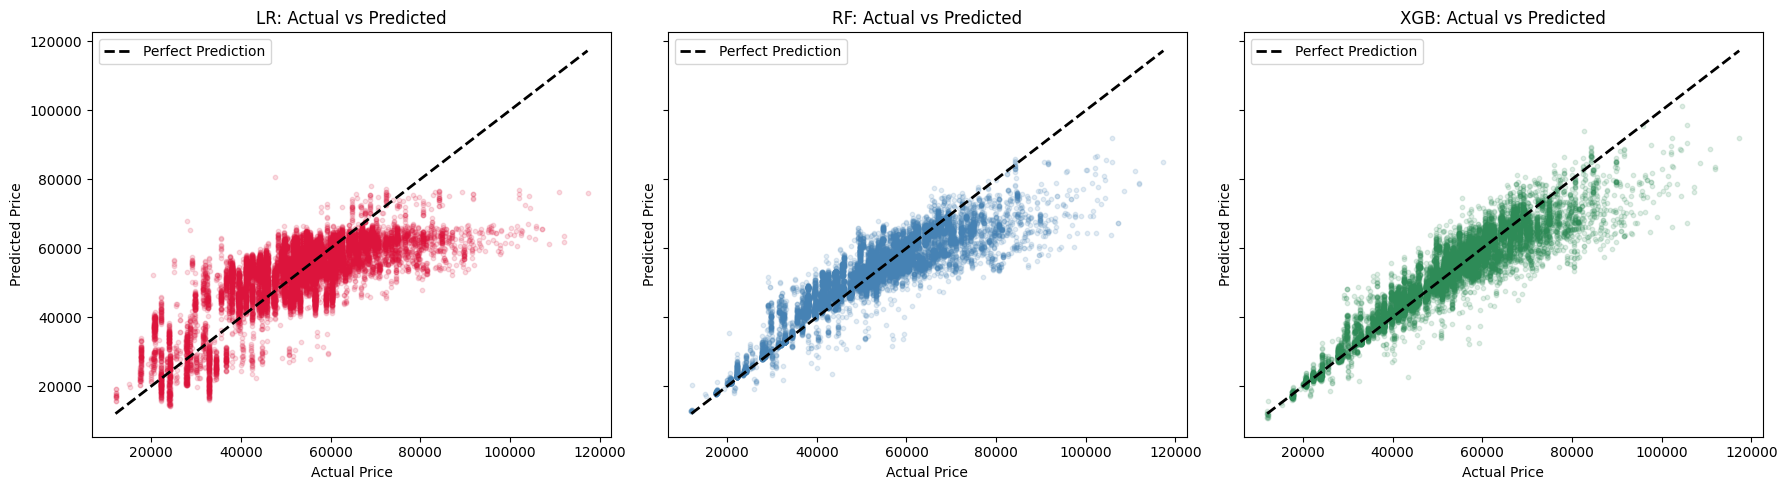

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

axes[0].scatter(y_test, y_pred_lr, s=10, alpha=0.15, color='crimson')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color='black', label='Perfect Prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('LR: Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_test, y_pred_rf, s=10, alpha=0.15, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color='black', label='Perfect Prediction')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('RF: Actual vs Predicted')
axes[1].legend()

axes[2].scatter(y_test, y_pred_xgb, s=10, alpha=0.15, color='seagreen')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color='black', label='Perfect Prediction')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')
axes[2].set_title('XGB: Actual vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()

## y_pred_lr Vs Residuals Vs 0 error line plot comparision

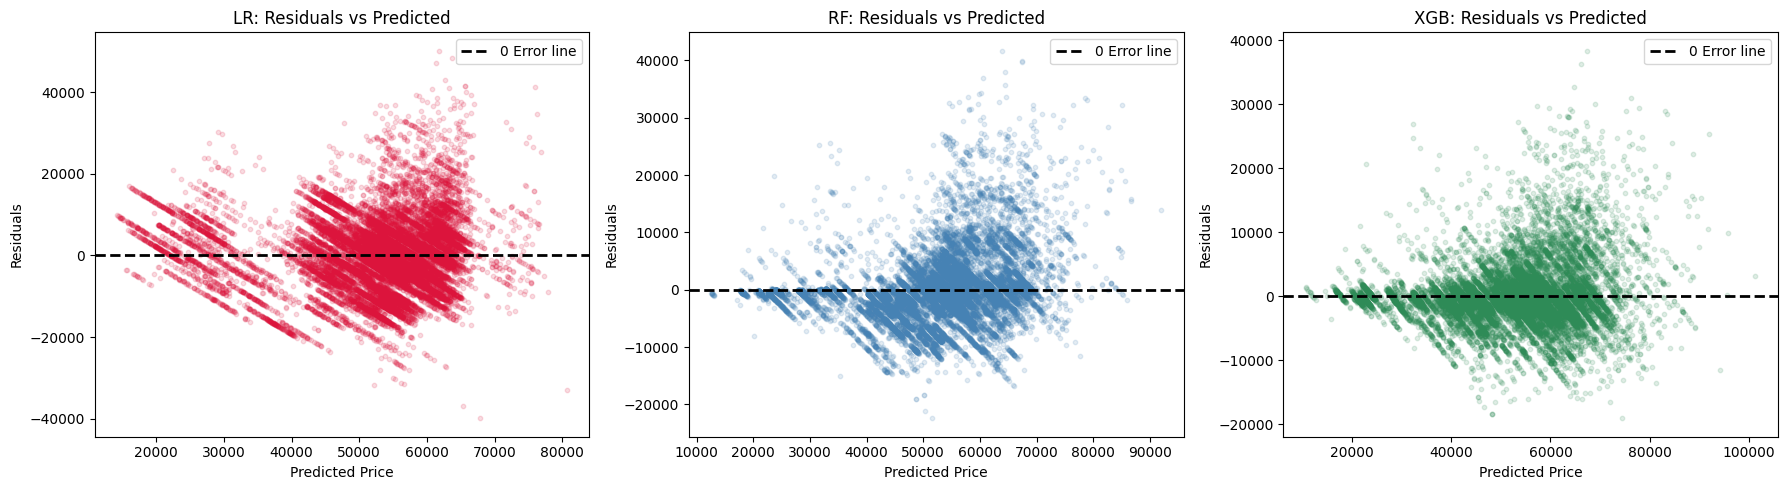

In [41]:
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf
residuals_xgb = y_test - y_pred_xgb

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_lr, residuals_lr, color='crimson', s=10, alpha=0.15)
axes[0].axhline(y=0, color='black', linewidth=2, linestyle='--', label='0 Error line')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('LR: Residuals vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_rf, residuals_rf, color='steelblue', s=10, alpha=0.15)
axes[1].axhline(y=0, color='black', linewidth=2, linestyle='--', label='0 Error line')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('RF: Residuals vs Predicted')
axes[1].legend()

axes[2].scatter(y_pred_xgb, residuals_xgb, color='seagreen', s=10, alpha=0.15)
axes[2].axhline(y=0, color='black', linewidth=2, linestyle='--', label='0 Error line')
axes[2].set_xlabel('Predicted Price')
axes[2].set_ylabel('Residuals')
axes[2].set_title('XGB: Residuals vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()

## Residuals distribution and skewness comparision

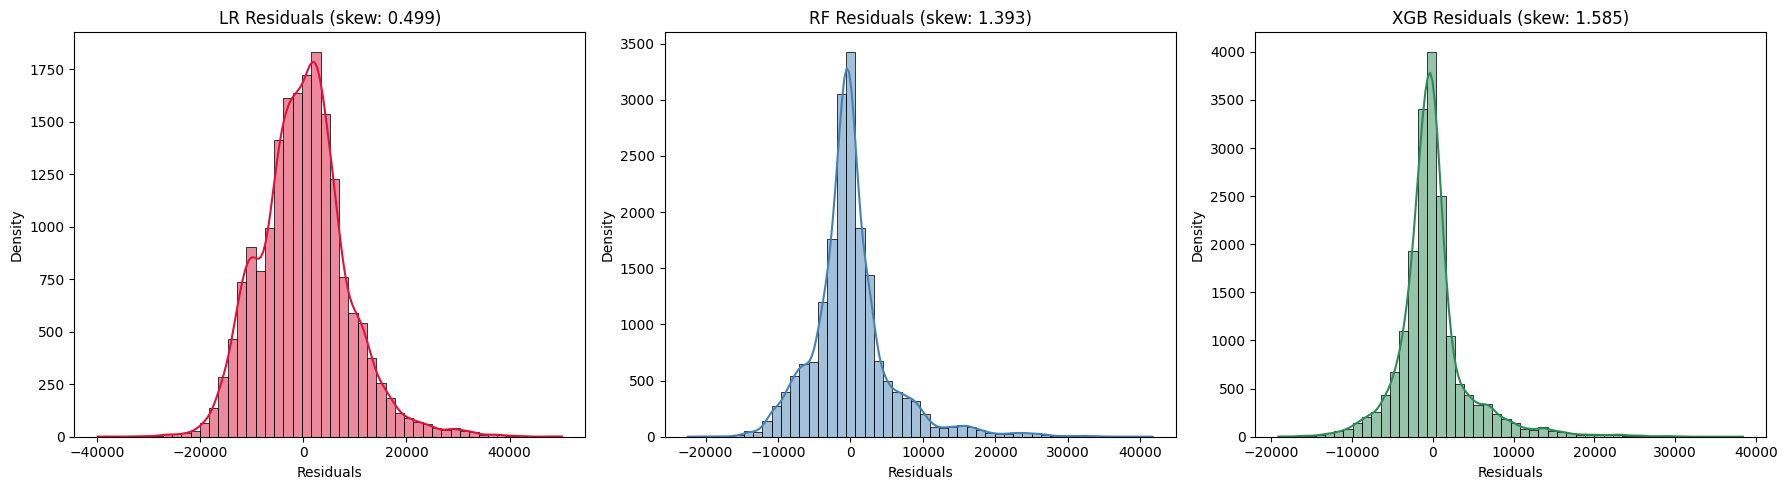

LR residuals skew: 0.49913073144704845
RF residuals skew: 1.3927258519116346
XGB residuals skew: 1.5849896044332463


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(residuals_lr, bins=50, kde=True, color='crimson', ax=axes[0])
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Density')
axes[0].set_title(f'LR Residuals (skew: {residuals_lr.skew():.3f})')

sns.histplot(residuals_rf, bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Density')
axes[1].set_title(f'RF Residuals (skew: {residuals_rf.skew():.3f})')

sns.histplot(residuals_xgb, bins=50, kde=True, color='seagreen', ax=axes[2])
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Density')
axes[2].set_title(f'XGB Residuals (skew: {residuals_xgb.skew():.3f})')

plt.tight_layout()
plt.show()

print('LR residuals skew:', residuals_lr.skew())
print('RF residuals skew:', residuals_rf.skew())
print('XGB residuals skew:', residuals_xgb.skew())

## Final Comparison — Business Class

| Model | R² | RMSE | RMSE % of median |
|---|---|---|---|
| Linear Regression | 0.5613 | ₹8,613 | 16.19% |
| Random Forest | 0.8144 | ₹5,602 | 10.53% |
| XGBoost | 0.8788 | ₹4,527 | 8.51% |

- XGBoost sabse best hai teeno metrics mein
- LR sabse peeche hai — non-linear/threshold relationships (stop_count, duration, days_left last-minute spike) ko straight line se capture nahi kar pata
- RF aur XGB dono tree-based hone ki wajah se ye patterns natively pakad lete hain, boosting (XGB) ne RF se bhi thoda better fit diya
- Residual skew XGB mein sabse zyada hai — best average error ke sath bhi, kuch high-price flights par bada miss ho sakta hai, deployment se pehle in outlier cases ko check karna chahiye